In [1]:
%run "/home/nichettg/Ubuntu/Laboratorio/moduli.py"

In [2]:
titolo = "Esperienza"
xlabel = "x"
ylabel = "y"

file_input = "dati.csv"
file_output1 = "residui.txt"
file_output2 = "chi.txt"
grafico_output1 = "grafico.pdf"
grafico_output2 = "residui.pdf"
grafico_output3 = "chi.pdf"

### 1. Lettura

In [3]:
data = f.csv_to_dict(file_input)

### 2. Analisi

Regressione

In [4]:
xdata = np.array([data["x"],data["sx"]])
ydata = np.array([data["y"],data["sy"]])
def modello(par, x):
    return par[0] + par[1]*x

anal = f.fit(xdata,ydata,modello,[0,1])

Residui

In [5]:
f.inizializza_output(file_output1)
res = f.residui(xdata,ydata,anal[:,0],modello,file_output1,titolo)

Chi Quadro

In [6]:
f.inizializza_output(file_output2)
chi = f.chi_quadro(xdata,ydata,anal[:,0],modello,file_output2,titolo)

### 3. Grafici

Regressione

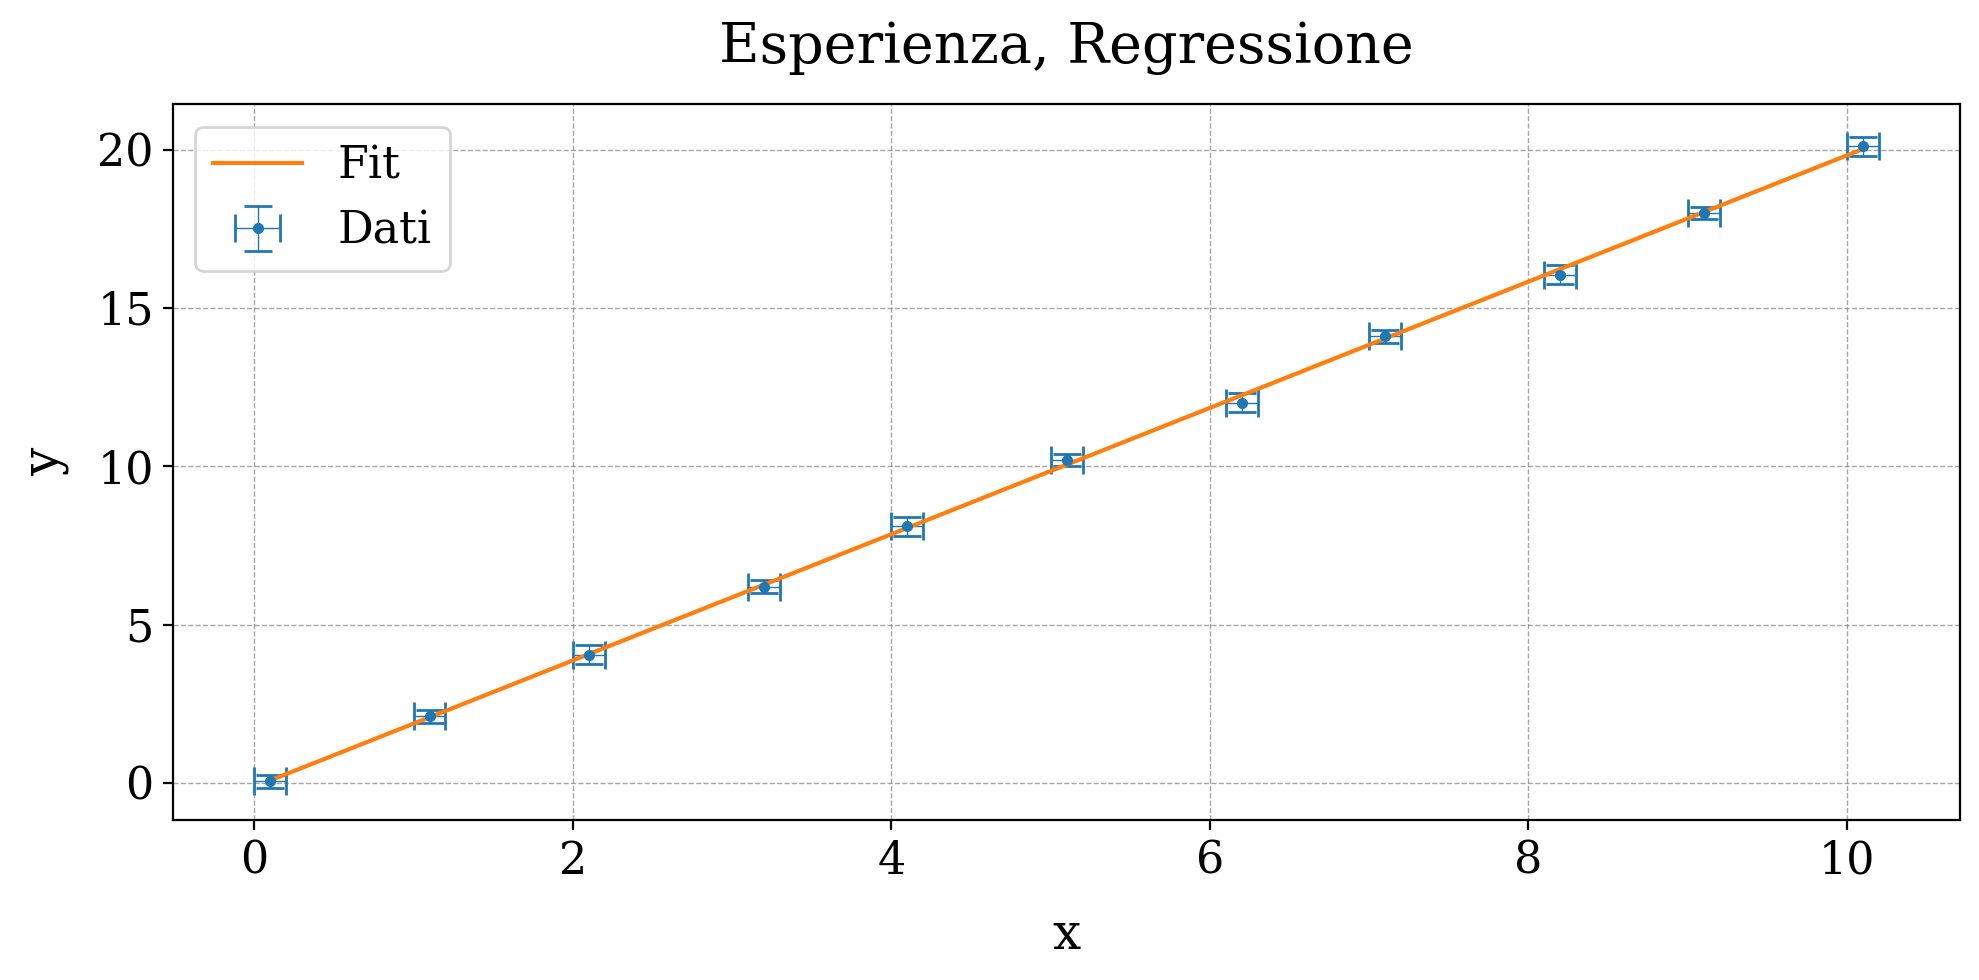

In [7]:
fig,ax = plt.subplots(1, 1,  figsize=(10, 5))
gf.parametri_grafico(ax,titolo + ", Regressione",xlabel=xlabel,ylabel=ylabel)
# Grafico dei dati con errori
ax.errorbar(xdata[0],ydata[0],xerr=xdata[1],yerr=ydata[1],
            label="Dati", **gf.errorbar_params, color = gf.colori[0])
# Grafico del fit
x_fit = np.linspace(min(xdata[0]), max(xdata[0]), 500)
ax.plot(x_fit,modello(anal[:,0],x_fit),
        label="Fit", **gf.plot_params, color = gf.colori[1])

ax.legend()

gf.salva_grafico(fig,grafico_output1)

Residui

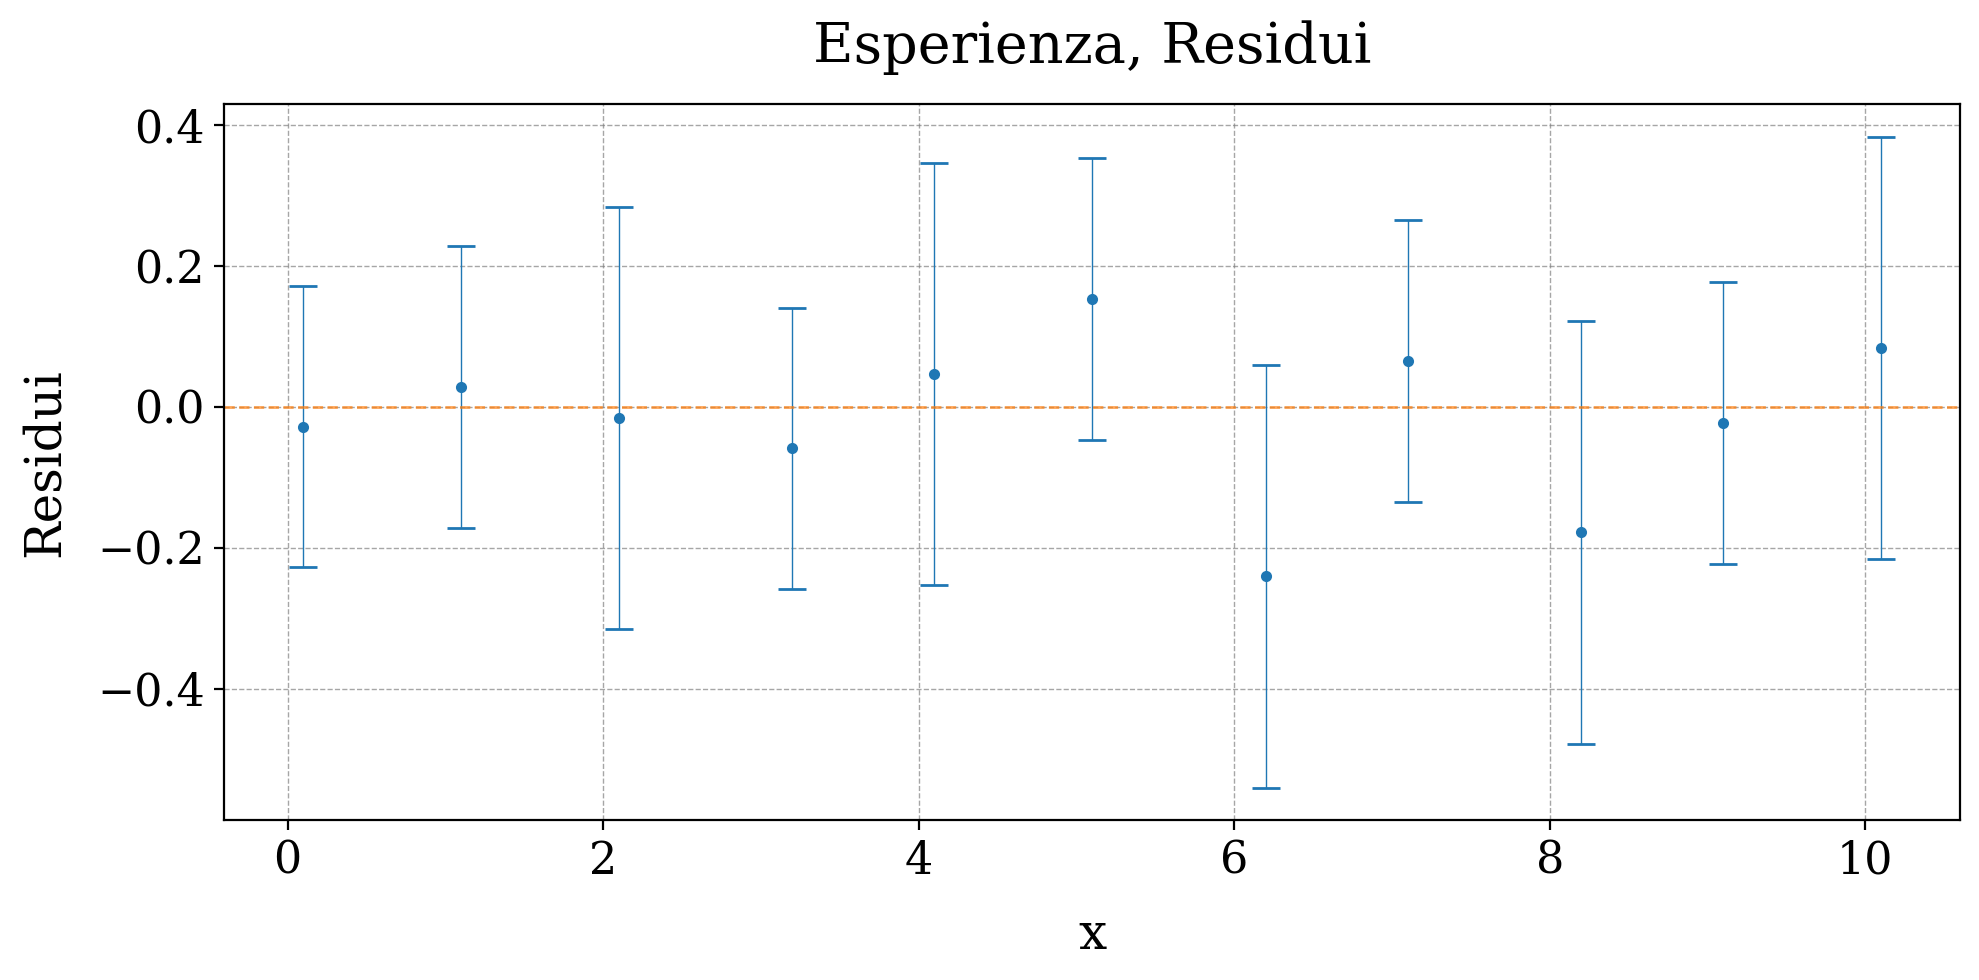

In [8]:
fig,ax = plt.subplots(1, 1,  figsize=(10, 5))
gf.parametri_grafico(ax,titolo + ", Residui",xlabel=xlabel,ylabel="Residui")

ax.errorbar(res[0],res[1],yerr=res[2],
            **gf.errorbar_params, color=gf.colori[0])
ax.axhline(0,
           **gf.line_params, color=gf.colori[1])

gf.salva_grafico(fig,grafico_output2)

Chi Quadro

<>:2: SyntaxWarning: invalid escape sequence '\c'
<>:2: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_15342/1845354324.py:2: SyntaxWarning: invalid escape sequence '\c'
  gf.parametri_grafico(ax,titolo + r", $\chi^2$",xlabel=xlabel,ylabel="$\chi^2$")


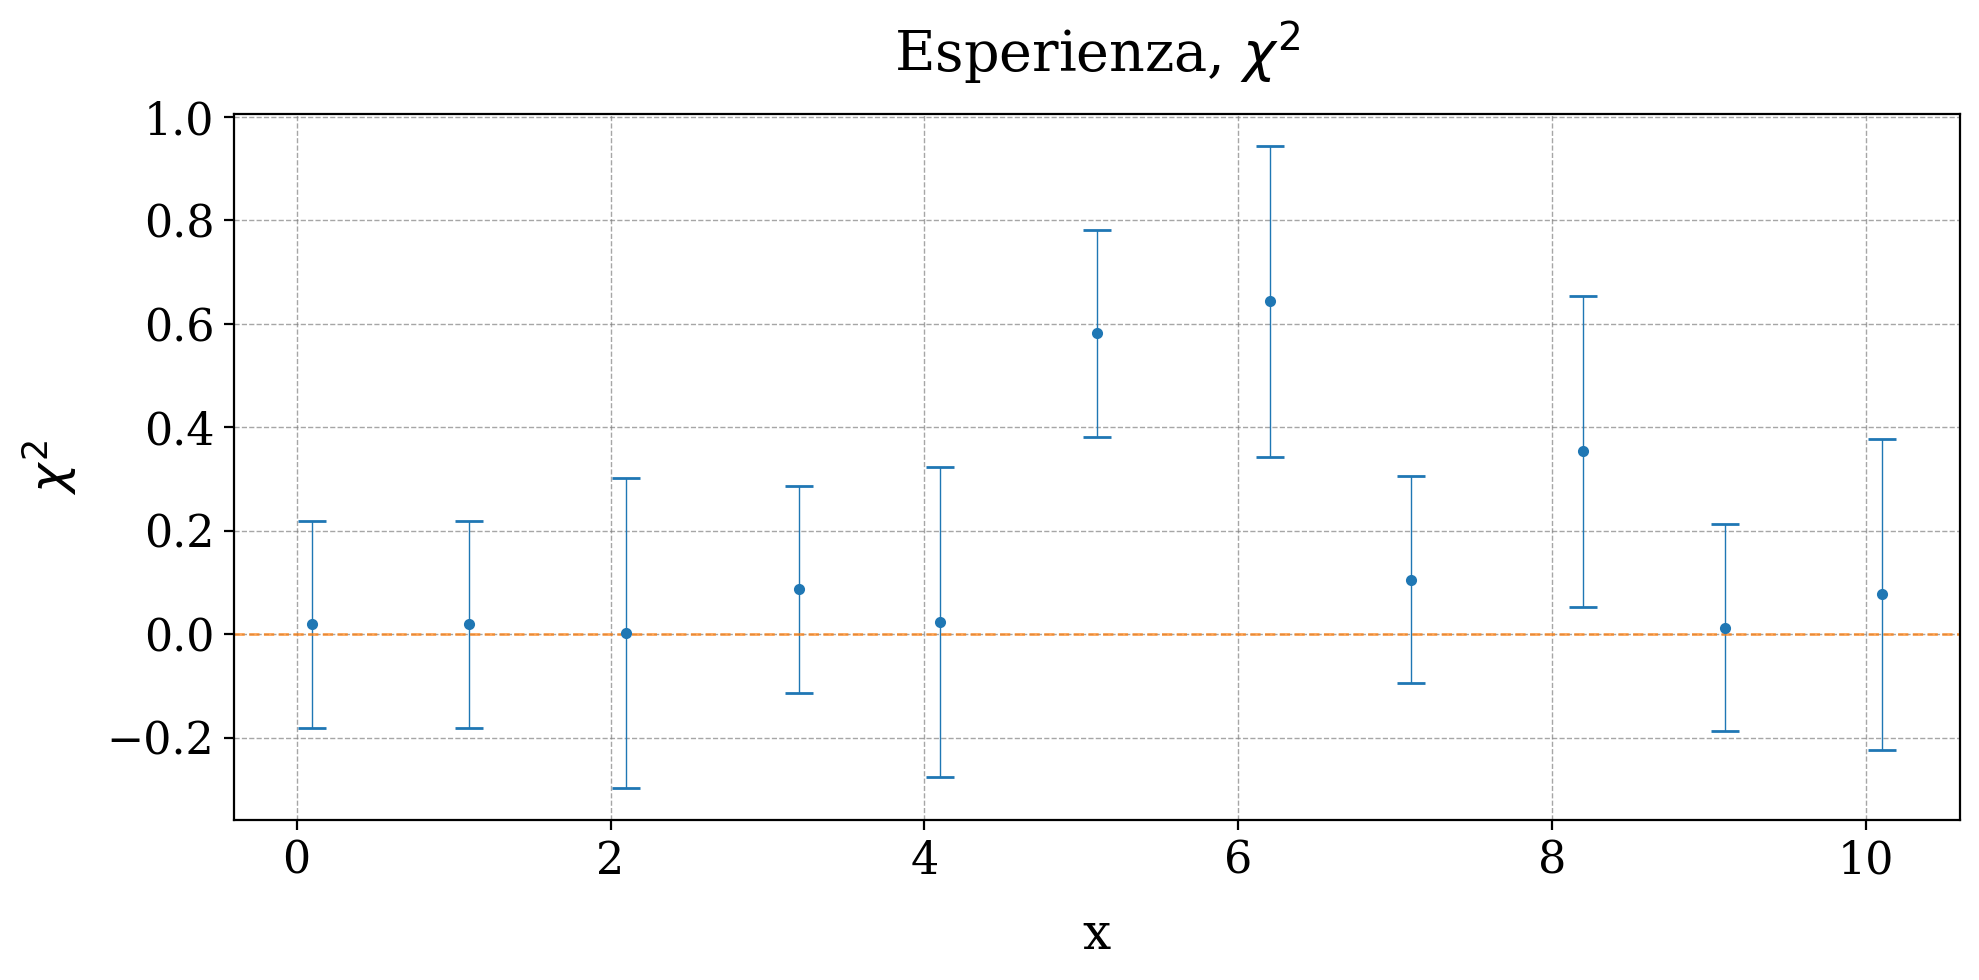

In [9]:
fig,ax = plt.subplots(1, 1,  figsize=(10, 5))
gf.parametri_grafico(ax,titolo + r", $\chi^2$",xlabel=xlabel,ylabel="$\chi^2$")

ax.errorbar(chi[0],chi[1],yerr=chi[2],
            **gf.errorbar_params, color=gf.colori[0])
ax.axhline(0,
           **gf.line_params, color=gf.colori[1])

gf.salva_grafico(fig,grafico_output3)